# Evaluación Parcial N°2: Programación para la Ciencia de Datos (SCY1101)
# Hito 1: Análisis Exploratorio de Datos (EDA) - Diagnóstico de Datos Originales
# 1. Contexto del Problema de Negocio
En el escenario comercial actual, entender el comportamiento del consumidor y anticipar la pérdida de clientes es un factor crítico para la rentabilidad de la empresa. Este proyecto aborda un problema de negocio real enfocado en la gestión de relaciones con el cliente (CRM) y la predicción de abandono (Churn).

Para resolver esto mediante Machine Learning, contamos con una base de datos histórica (dataset_clientes.csv) que registra variables demográficas, financieras y de comportamiento de los usuarios, incluyendo si el cliente dejó la empresa o no


# 2. Objetivo de este Notebook
Antes de implementar cualquier algoritmo predictivo, la regla de oro de la Ciencia de Datos exige auditar la calidad de la información. Por lo tanto, este notebook se enfoca exclusivamente en el Análisis Exploratorio de Datos (EDA) sobre el dataset original ("sucio").

El propósito de esta fase es puramente de diagnóstico:

Identificar Vacíos de Información: Detectar variables con valores faltantes (nulos) que requieran estrategias de imputación.

Detectar Valores Atípicos (Outliers): Localizar anomalías numéricas o errores de registro (ej. edades imposibles, ingresos distorsionados) que puedan sesgar un modelo.

Evaluar Inconsistencias: Exponer problemas de formato, duplicados o textos mal ingresados.

# 3. Estructura del Análisis Visual
A continuación, se presentan las estadísticas descriptivas y las visualizaciones gráficas (histogramas, diagramas de caja y gráficos de barras) diseñadas específicamente para mapear y evidenciar la "mugre" o ruido que contienen los datos en su estado bruto. Este análisis servirá como justificación técnica para el posterior proceso de preprocesamiento y limpieza de datos.



In [1]:
!wget https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv

--2026-05-25 06:58:16--  https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282843 (3.1M) [text/plain]
Saving to: ‘dataset_clientes.csv’

dataset_clientes.cs 100%[===================>]   3.13M  14.1MB/s    in 0.2s    

2026-05-25 06:58:17 (14.1 MB/s) - ‘dataset_clientes.csv’ saved [3282843/3282843]



#Importamos las librerias necesarias para porcentajes y graficos

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

#Cargar csv


In [3]:
data = pd.read_csv('dataset_clientes.csv')

In [4]:
data.shape

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

In [5]:
data.describe()

,id_cliente,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,abandono
count,20400.000000,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,10004.989853,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147,0.396814
std,5767.007342,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998,0.489249
min,1.000000,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000,0.000000
25%,5016.750000,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000,0.000000
50%,10014.500000,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000,0.000000
75%,14984.250000,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000,1.000000
max,20000.000000,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000,1.000000


In [6]:
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


# VALORES NULOS

In [28]:
data.isnull().sum()

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1021
gasto_mensual,1025
deuda_total,0
score_crediticio,1021


# VARIABLE OBJETIVO A ANALIZAR

In [30]:
data['abandono'].value_counts()

,count
abandono,
0,12305
1,8095


La variable objetivo del proyecto es la deserción de clientes. El propósito consiste en predecir si un cliente dejará o continuará utilizando el servicio.

# Se analizan las variables numéricas para identificar distribuciones, posibles valores atípicos y patrones relevantes para el modelado.

In [17]:
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

numeric_columns

Index(['id_cliente', 'edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total',
       'score_crediticio', 'antiguedad_meses', 'frecuencia_compra',
       'ultima_compra_dias', 'num_productos', 'tiene_tarjeta_credito',
       'hora_registro', 'codigo_postal', 'abandono'],
      dtype='object')

#Verificando los datos iniciales

In [7]:
# Verificamos en todo el dataset los duplicados exactos.
dups_totales = data.duplicated().sum()
print(f"Filas exactamente iguales: {dups_totales}")

# Como podemos podemos ver en el caso de estudio nuestra prioridad fue revisar id cliente, ya que nos mencionaba que existia la posibilidad de duplicados.
dups_id = data['id_cliente'].duplicated().sum()
print(f"ID's de cliente repetidos: {dups_id}")

Filas exactamente iguales: 400
ID's de cliente repetidos: 400


#REVISION DE ATIPICOS FINANCIEROS

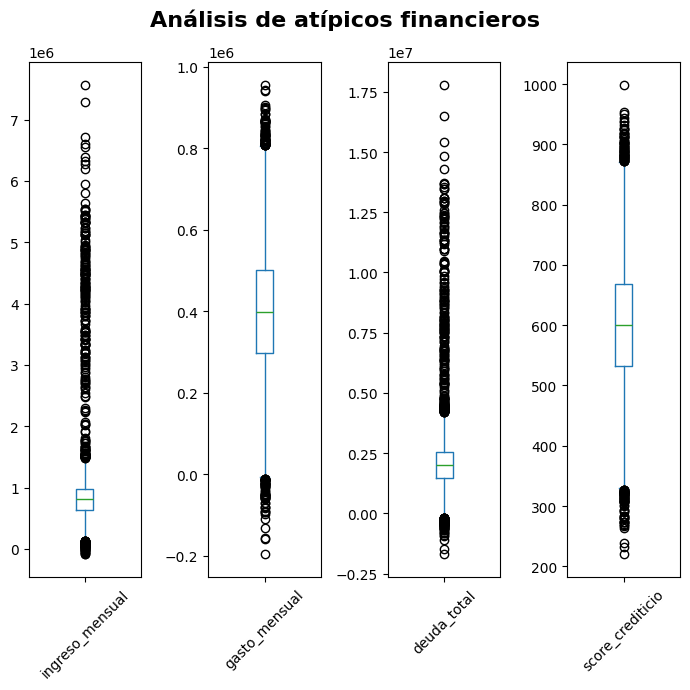

In [25]:
revision_atipicos_fin = ['ingreso_mensual', 'gasto_mensual', 'deuda_total',	'score_crediticio']
fig, axes = plt.subplots(1, 4, figsize=(18,6))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos_fin):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos financieros", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()
fig.savefig('revision_atipicos_fin.png')

# Graficamos las Variables Cuantitativas antes de Su limpieza PARA VER DISTRIBUCIÓN ANTES Y DESPSUÉS

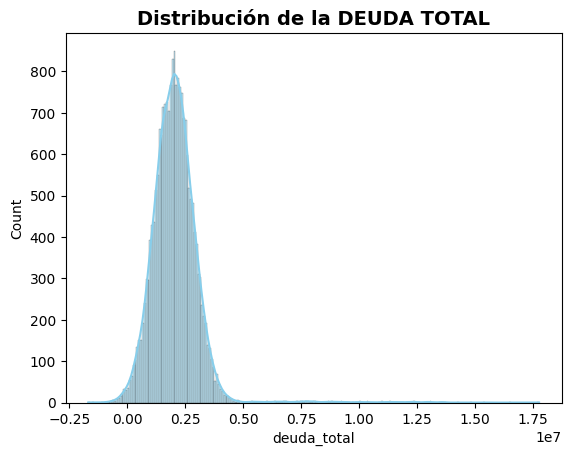

In [10]:
sns.histplot(data['deuda_total'], kde=True, color="skyblue")
plt.title('Distribución de la DEUDA TOTAL', fontsize=14, fontweight="bold")
plt.show()

fig.savefig('Distribución de la DEUDA TOTAL')

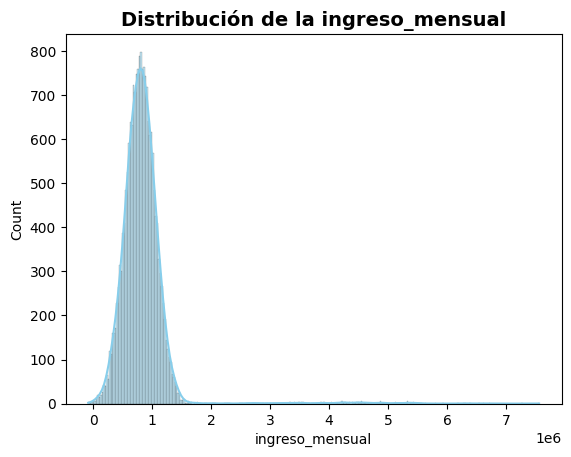

In [11]:
sns.histplot(data['ingreso_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la ingreso_mensual', fontsize=14, fontweight="bold")
plt.show()

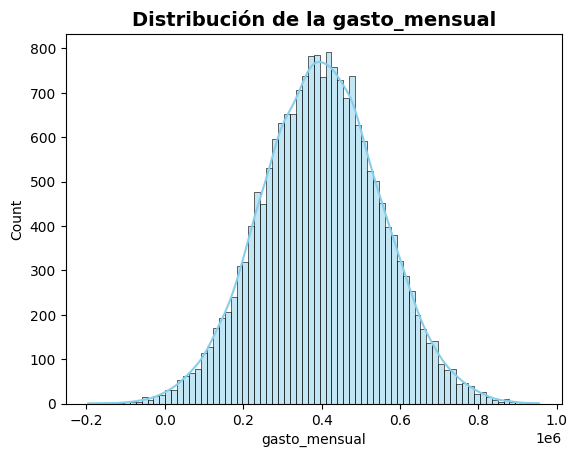

In [12]:
sns.histplot(data['gasto_mensual'], kde=True, color="skyblue")
plt.title('Distribución de la gasto_mensual', fontsize=14, fontweight="bold")
plt.show()

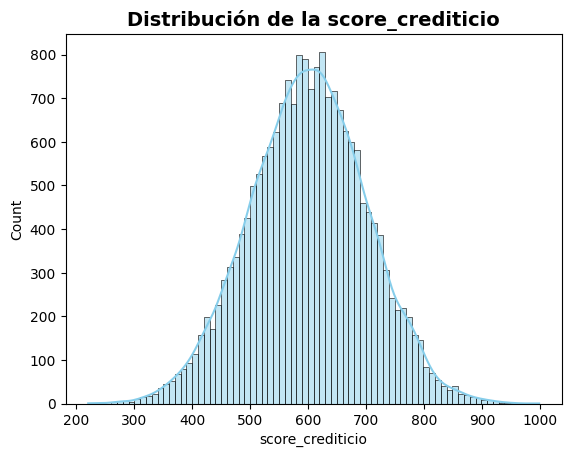

In [13]:
sns.histplot(data['score_crediticio'], kde=True, color="skyblue")
plt.title('Distribución de la score_crediticio', fontsize=14, fontweight="bold")
plt.show()

# matriz de correlación
La matriz de correlación de Pearson evidencia que las variables numéricas poseen correlaciones cercanas a cero respecto a la variable de abandono, indicando que no existen relaciones lineales fuertes. Esto sugiere que el abandono de clientes no depende de un único factor, sino de la combinación de múltiples variables.

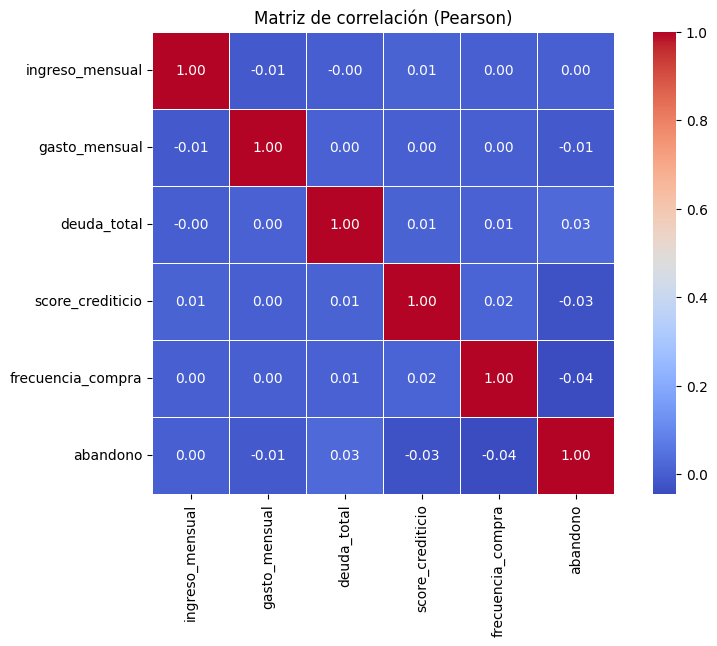

In [35]:
cols_corr = [
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "frecuencia_compra",
    "abandono"
]

corr_pearson = data[cols_corr].corr(method="pearson")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Pearson)")
plt.show()

# histogramas
 Los histogramas ayudan a visualizar cómo se distribuyen las variables numéricas, permitiendo detectar posibles sesgos, valores atípicos y agrupaciones de datos.

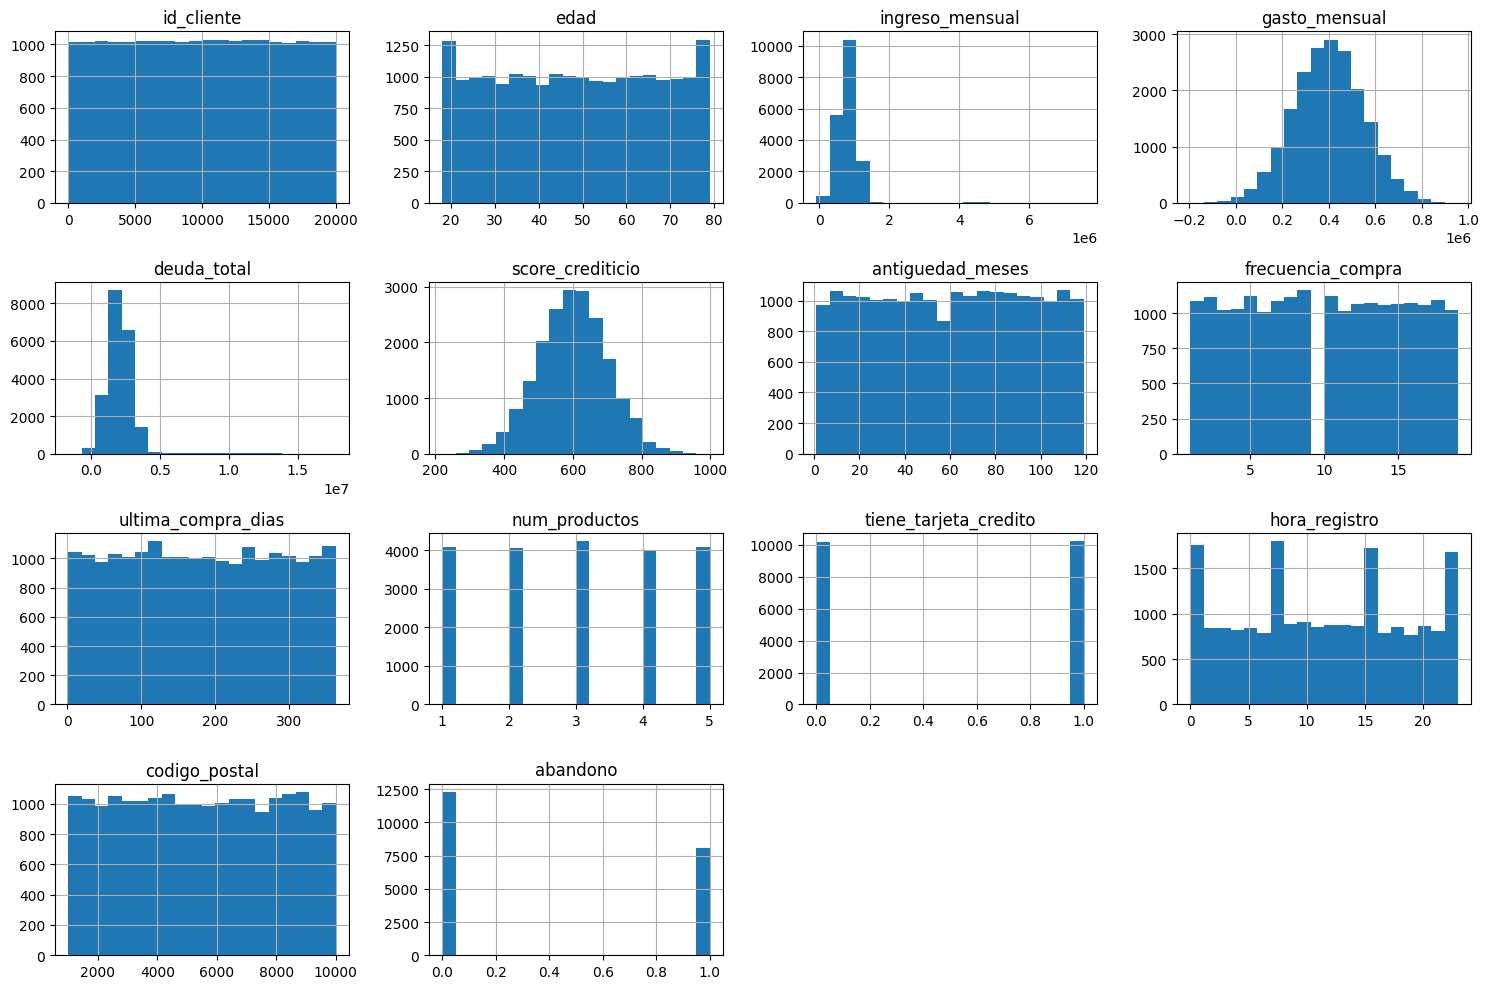

In [34]:


numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

data[numeric_columns].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

#Gráfico para averiguar por tipo de plan o región
#cuál tiene más tasa abandonos

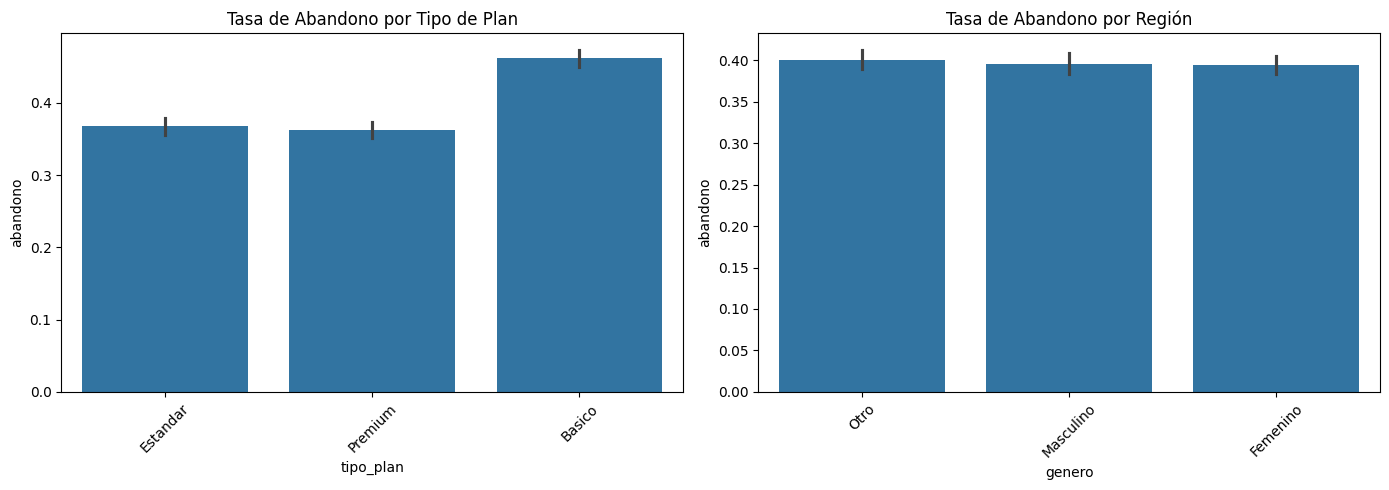

In [31]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='tipo_plan', y='abandono', data=data)
plt.title('Tasa de Abandono por Tipo de Plan')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='genero', y='abandono', data=data)
plt.title('Tasa de Abandono por Región')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
reporte_planes = pd.crosstab(data['tipo_plan'], data['abandono'])
print("\nResumen por tipo de plan y abandono:")
print(reporte_planes)


Resumen por tipo de plan y abandono:
abandono      0     1
tipo_plan            
Basico     3582  3078
Estandar   4349  2529
Premium    4374  2488


# Conclusión: Diagnóstico de Calidad de Datos (Datos Sucios) Tras realizar el análisis exploratorio inicial y generar las visualizaciones de las variables originales, se detectaron múltiples anomalías y problemas de calidad de datos que impiden el uso directo de este dataset para modelos predictivos. Los hallazgos principales se detallan a continuación:  1. Presencia de Valores Faltantes (Missing Values)Se identificó que el dataset no está completo. Los gráficos de barras/conteo revelaron la ausencia de registros en variables. Entrenar un modelo con estos vacíos generaría errores de ejecución o sesgos severos en las predicciones.  2. Valores Atípicos y Fuera de Rango (Outliers)A través de los gráficos de caja (Boxplots) e histogramas, se evidenciaron inconsistencias numéricas graves como valores que no hacen sentido para el contexto del negocio que distorsionan la distribución real de los clientes.